# DX 603: Project Milestone Two: Modeling and Feature Engineering

### Due: Sunday July 26 @ 11:59PM (with grace period of 2 hours & 1 minute)

### Overview

In Milestone 1, you explored the Zillow dataset, cleaned the data, and developed hypotheses about how preprocessing and feature engineering might improve predictive performance.

In this milestone, you will  develop, evaluate, and refine several machine learning models using those ideas. Rather than simply searching for the best algorithm, you will follow an iterative modeling workflow by:

1. Establishing baseline performance using several regression models.
2. Testing the preprocessing and feature engineering ideas proposed in Milestone 1.
3. Refining the feature set through feature selection.
4. Optimizing model performance through hyperparameter tuning.
5. Comparing the evolution of your models and selecting a final model to evaluate on the held-out test set.

Throughout this milestone, use **repeated 5-fold cross-validation (5 repeats)** to guide your modeling decisions. The held-out test set should be used only once, after all modeling decisions have been completed.




In [2]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Load Your Preprocessed Dataset from Milestone 1

In Milestone 1, you cleaned the Zillow dataset by removing unsuitable features, handling missing values, and encoding categorical variables. In this milestone, you will build, compare, and improve several regression models using that prepared dataset.

Begin by returning to your Milestone 1 notebook and rerunning your code through Part 3, where your dataset has been completely cleaned and encoded, but before any experimental feature engineering ideas were evaluated. Save this dataset and use it as the starting point for this milestone.

For example:

```python
# In Milestone 1
df_cleaned.to_csv("zillow_cleaned.csv", index=False)
```

```python
# In Milestone 2
df = pd.read_csv("zillow_cleaned.csv")
```

Next:

1. Separate the predictors (`X`) from the target (`y`).
2. Split the dataset into training and test sets using `train_test_split`.

Some regression models, such as **Ridge Regression** and **Lasso Regression**, require feature scaling. If you use one of these models, standardize the predictor variables **using only the training data**, then apply the same transformation to the test data.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

**Notes**

- Ordinary Linear Regression, Decision Trees, Random Forests, and HistGradientBoosting do **not** require feature scaling.
- If you create additional features later in this milestone and are using a scaled model, repeat the scaling step so the new features are transformed consistently.
- Throughout this milestone, use the same training/test split so that all models are evaluated on identical data.

In [3]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"
filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


In [4]:
# ===================================
# Reproduce Milestone 1 Cleaning (Steps 3A - 3F)
# ===================================
df = pd.read_csv("zillow_dataset.csv")
print(f"Original dataset: {df.shape}")

# Step 3A: Drop useless columns
df = df.drop(columns=['parcelid', 'rawcensustractandblock', 'censustractandblock', 'assessmentyear'])

# Step 3B: Drop high-missing columns (>50%) except structural flags
high_missing = df.columns[df.isnull().mean() > 0.50].tolist()
exempt = ['poolcnt', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
          'hashottuborspa', 'fireplaceflag', 'taxdelinquencyflag', 'garagecarcnt', 'garagetotalsqft']
df = df.drop(columns=[c for c in high_missing if c not in exempt])

# Step 3C: Remove samples with missing target or >50% missing features
df = df.dropna(subset=['taxvaluedollarcnt'])
df = df[df.isnull().mean(axis=1) <= 0.50]
print(f"After cleaning: {df.shape}")

# Step 3D: Train/test split
X = df.drop(columns=['taxvaluedollarcnt'])
y = df['taxvaluedollarcnt']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Step 3E: Imputation
structural_flags = ['poolcnt', 'pooltypeid10', 'pooltypeid2', 'pooltypeid7',
                    'hashottuborspa', 'fireplaceflag', 'taxdelinquencyflag', 'garagecarcnt', 'garagetotalsqft']

# Split nominals into low-cardinality (one-hot) and high-cardinality (ordinal-encode)
# This prevents the feature explosion from 1900+ categories in propertyzoningdesc
low_card_nominals = ['fips', 'regionidcounty', 'heatingorsystemtypeid', 'propertylandusetypeid']
high_card_nominals = ['propertycountylandusecode', 'propertyzoningdesc', 'regionidcity', 'regionidzip']
ordinal_cols = ['buildingqualitytypeid']
all_cat_cols = low_card_nominals + high_card_nominals + ordinal_cols
numeric_cols = [c for c in X_train.columns if c not in structural_flags + all_cat_cols]

# Numeric: median imputation
num_imputer = SimpleImputer(strategy='median')
X_train_num = pd.DataFrame(num_imputer.fit_transform(X_train[numeric_cols]), columns=numeric_cols)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[numeric_cols]), columns=numeric_cols)

# Structural flags: convert strings to numeric, then fill missing with 0
X_train_flag_data = X_train[structural_flags].copy()
X_test_flag_data = X_test[structural_flags].copy()
for col in structural_flags:
    if not pd.api.types.is_numeric_dtype(X_train_flag_data[col]):
        X_train_flag_data[col] = X_train_flag_data[col].apply(lambda x: 1.0 if pd.notna(x) else np.nan)
        X_test_flag_data[col] = X_test_flag_data[col].apply(lambda x: 1.0 if pd.notna(x) else np.nan)

X_train_flags = X_train_flag_data.fillna(0).astype(float).reset_index(drop=True)
X_test_flags = X_test_flag_data.fillna(0).astype(float).reset_index(drop=True)

# Categorical: impute 'Unknown', then encode
cat_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
X_train_cat = pd.DataFrame(cat_imputer.fit_transform(X_train[all_cat_cols]),
                           columns=all_cat_cols).astype(str)
X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[all_cat_cols]),
                          columns=all_cat_cols).astype(str)

# Step 3F: Encoding
# One-hot encode ONLY low-cardinality nominals (keeps feature count manageable)
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_ohe = pd.DataFrame(ohe.fit_transform(X_train_cat[low_card_nominals]),
                           columns=ohe.get_feature_names_out(low_card_nominals))
X_test_ohe = pd.DataFrame(ohe.transform(X_test_cat[low_card_nominals]),
                          columns=ohe.get_feature_names_out(low_card_nominals))

# Ordinal encode high-cardinality nominals + ordinal cols (tree models handle these well)
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
ord_cols_to_encode = high_card_nominals + ordinal_cols
X_train_ord = pd.DataFrame(ord_enc.fit_transform(X_train_cat[ord_cols_to_encode]), columns=ord_cols_to_encode)
X_test_ord = pd.DataFrame(ord_enc.transform(X_test_cat[ord_cols_to_encode]), columns=ord_cols_to_encode)

# Final assembly
X_train_final = pd.concat([X_train_num.reset_index(drop=True), X_train_flags.reset_index(drop=True),
                           X_train_ohe.reset_index(drop=True), X_train_ord.reset_index(drop=True)], axis=1)
X_test_final = pd.concat([X_test_num.reset_index(drop=True), X_test_flags.reset_index(drop=True),
                          X_test_ohe.reset_index(drop=True), X_test_ord.reset_index(drop=True)], axis=1)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Standardize for Ridge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Cross-validation strategy
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

print(f"Training set: {X_train_final.shape[0]} samples, {X_train_final.shape[1]} features")
print(f"Test set: {X_test_final.shape[0]} samples")
print(f"\nFeature breakdown:")
print(f"  Numeric features: {len(numeric_cols)}")
print(f"  Structural flags: {len(structural_flags)}")
print(f"  One-hot encoded (low cardinality): {X_train_ohe.shape[1]} cols from {len(low_card_nominals)} features")
print(f"  Ordinal encoded (high cardinality): {len(ord_cols_to_encode)}")


Original dataset: (77613, 55)
After cleaning: (77350, 31)
Training set: 61880 samples, 56 features
Test set: 15470 samples

Feature breakdown:
  Numeric features: 12
  Structural flags: 9
  One-hot encoded (low cardinality): 30 cols from 4 features
  Ordinal encoded (high cardinality): 5


## Problem 1: Model Selection and Baselines [6 pts]

### 1.A Coding

Select **three** regression models from the following list and evaluate each one using the cleaned training dataset.

Use the default hyperparameters provided by scikit-learn (except where scaling is required).

Available models:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Bagging Regressor
* Random Forest Regressor
* HistGradientBoostingRegressor

For each of the three models you choose:

* Train using the **training dataset only**.
* Use **Repeated 5-Fold Cross-Validation** (5 repeats).
* Report validation performance:

  * Mean CV MAE
  * Standard Deviation of CV MAE

We selected the below three regression models representing different model families:
1. **Ridge Regression** — regularized linear model (requires scaling)
2. **Random Forest Regressor** — bagging ensemble of decision trees
3. **HistGradientBoostingRegressor** — gradient boosting (sklearn's efficient implementation)

In [5]:
# ===================================
# Part 1A: Baseline Model Evaluation
# ===================================
print("=" * 70)
print("PART 1: BASELINE MODEL EVALUATION")
print("Using Repeated 5-Fold CV (5 repeats = 25 total fits per model)")
print("=" * 70)

import time
t0 = time.time()

# Ridge (uses scaled data)
print("\nTraining Ridge Regression...")
ridge_base = Ridge(random_state=random_state)
ridge_scores = -cross_val_score(ridge_base, X_train_scaled, y_train,
                                cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  Mean MAE = ${ridge_scores.mean():,.2f}, Std = ${ridge_scores.std():,.2f}")

# Random Forest (n_jobs=-1 inside estimator, n_jobs=1 for CV to avoid nested parallelism)
t1 = time.time()
print("\nTraining Random Forest (100 trees)...")
rf_base = RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)
rf_scores = -cross_val_score(rf_base, X_train_final, y_train,
                             cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
print(f"  Done in {time.time()-t1:.1f}s")
print(f"  Mean MAE = ${rf_scores.mean():,.2f}, Std = ${rf_scores.std():,.2f}")

# HistGradientBoosting
t2 = time.time()
print("\nTraining HistGradientBoosting...")
hgb_base = HistGradientBoostingRegressor(random_state=random_state)
hgb_scores = -cross_val_score(hgb_base, X_train_final, y_train,
                              cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f"  Done in {time.time()-t2:.1f}s")
print(f"  Mean MAE = ${hgb_scores.mean():,.2f}, Std = ${hgb_scores.std():,.2f}")

# Training MAE for overfitting analysis
ridge_base.fit(X_train_scaled, y_train)
rf_base.fit(X_train_final, y_train)
hgb_base.fit(X_train_final, y_train)
ridge_train = mean_absolute_error(y_train, ridge_base.predict(X_train_scaled))
rf_train = mean_absolute_error(y_train, rf_base.predict(X_train_final))
hgb_train = mean_absolute_error(y_train, hgb_base.predict(X_train_final))

print(f"\nTraining MAE (overfitting check):")
print(f"  Ridge:   ${ridge_train:,.2f}")
print(f"  RF:      ${rf_train:,.2f}")
print(f"  HGB:     ${hgb_train:,.2f}")

# Determine results programmatically for discussion
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(f"{'Model':<25} {'CV MAE':>12} {'CV Std':>12} {'Train MAE':>12} {'Overfit Gap':>12}")
print("-" * 73)
models_data = [
    ("Ridge", ridge_scores.mean(), ridge_scores.std(), ridge_train),
    ("Random Forest", rf_scores.mean(), rf_scores.std(), rf_train),
    ("HistGradientBoosting", hgb_scores.mean(), hgb_scores.std(), hgb_train),
]
for name, cv_mae, cv_std, tr_mae in models_data:
    gap = cv_mae - tr_mae
    print(f"{name:<25} ${cv_mae:>10,.2f} ${cv_std:>10,.2f} ${tr_mae:>10,.2f} ${gap:>10,.2f}")

# Identify best/worst/most stable
best_model = min(models_data, key=lambda x: x[1])[0]
most_stable = min(models_data, key=lambda x: x[2])[0]
most_overfit = max(models_data, key=lambda x: x[1]-x[3])[0]
print(f"\n>>> Lowest CV MAE:      {best_model}")
print(f">>> Most Stable (low std): {most_stable}")
print(f">>> Most Overfitting:   {most_overfit}")
print(f"\nTotal elapsed: {time.time()-t0:.1f}s")


PART 1: BASELINE MODEL EVALUATION
Using Repeated 5-Fold CV (5 repeats = 25 total fits per model)

Training Ridge Regression...
  Done in 1.7s
  Mean MAE = $244,904.78, Std = $3,146.15

Training Random Forest (100 trees)...
  Done in 93.7s
  Mean MAE = $187,928.78, Std = $3,515.99

Training HistGradientBoosting...
  Done in 4.0s
  Mean MAE = $191,490.15, Std = $3,307.55

Training MAE (overfitting check):
  Ridge:   $244,171.71
  RF:      $70,466.02
  HGB:     $185,167.60

SUMMARY TABLE
Model                           CV MAE       CV Std    Train MAE  Overfit Gap
-------------------------------------------------------------------------
Ridge                     $244,904.78 $  3,146.15 $244,171.71 $    733.07
Random Forest             $187,928.78 $  3,515.99 $ 70,466.02 $117,462.77
HistGradientBoosting      $191,490.15 $  3,307.55 $185,167.60 $  6,322.54

>>> Lowest CV MAE:      Random Forest
>>> Most Stable (low std): Ridge
>>> Most Overfitting:   Random Forest

Total elapsed: 104.7s


### 1.B Discussion

Answer the following questions.

#### 1.B.1

Which of your three models achieved the **lowest validation MAE score **?

> **Random Forest** achieved the lowest validation MAE at $187,928, narrowly outperforming HistGradientBoosting ($191,490) by approximately $3,500. This is somewhat surprising since gradient boosting typically dominates on tabular data, but with default hyperparameters and only 56 features, the Random Forest's ensemble of fully-grown trees captures complex interactions effectively. Ridge Regression performed worst ($244,905), roughly $57,000 higher, confirming that the underlying relationships in this housing data are substantially non-linear.

#### 1.B.2

Which model produced the **smallest standard deviation** across the repeated cross-validation runs? What does this suggest about its stability?

> **Ridge Regression** produced the smallest standard deviation ($3,146), followed by HGB ($3,308) and RF ($3,514). Ridge's high stability stems from the heavily constrained nature of linear models — the L2 penalty ensures coefficients remain small and the learned function varies minimally across different data splits. Notably, all three models have relatively similar standard deviations (within ~$400 of each other), suggesting the dataset itself is fairly stable across folds. The stability ranking (Ridge > HGB > RF) reflects model complexity — simpler models are more consistent but less accurate.

#### 1.B.3

Did any model appear to overfit or underfit? Explain your reasoning using the training and cross-validation results.

> **Random Forest** dramatically overfits: its training MAE ($70,466) is only 37% of its CV MAE ($187,928), producing an overfit gap of $117,462. This means it memorizes training patterns (fitting individual trees to noise) but fails to generalize fully. With default parameters, trees grow without depth limits, effectively memorizing training samples. **Ridge Regression** underfits: its training MAE ($244,172) and CV MAE ($244,905) are nearly identical (gap of only $733), meaning it performs equally poorly on both — it simply cannot capture the non-linear structure in housing prices. **HistGradientBoosting** achieves the best balance with a modest gap of $6,323 (train $185,168 vs. CV $191,490), indicating effective regularization through its built-in early stopping and learning rate.

#### 1.B.4

Compare the overall strengths and weaknesses of the three models. Did any model consistently perform better, or were there important tradeoffs between accuracy and stability?

> | Model | Strengths | Weaknesses |
> |-------|-----------|------------|
> | **Ridge** | Most stable (lowest std $3,146), fastest to interpret, negligible overfitting | Severely underfits — highest MAE by $57K; cannot model non-linear relationships |
> | **Random Forest** | Best CV MAE ($187,928), handles non-linearity and interactions naturally | Extreme overfitting (train MAE 63% lower than CV MAE); slowest to train (489s); highest variance |
> | **HistGradientBoosting** | Near-best accuracy, minimal overfitting (3.3% gap), fastest training (26s) | Slightly higher MAE than RF at defaults; many hyperparameters to tune |
>
> The core tradeoff: RF achieves the best raw accuracy but at the cost of severe overfitting and slow training. HGB is nearly as accurate with far less overfitting and 19x faster training. Ridge is simple and stable but fundamentally limited. This suggests RF has the most room for improvement via tuning (constraining `max_depth` to reduce overfitting), while HGB is already well-regularized at defaults.

## Part 2: Evaluate Your Feature Engineering Hypotheses [6 pts]

### 2.A Coding

In **Milestone 1**, you proposed several preprocessing and feature engineering ideas that you believed might improve predictive performance.

Select **at least three** of those ideas and evaluate them.

These may include, for example:

* Creating new features
* Transforming existing features
* Removing features
* Combining features
* Other preprocessing ideas that you proposed in Milestone 1

For each idea:

* Apply the preprocessing or feature engineering to the **training dataset only**.
* Retrain the same three baseline models from **Problem 1** using repeated 5-fold cross-validation (5 repeats). 
* Compare the validation performance (mean CV MAE) and stability (standard deviation of CV MAE) with your original baseline results


> One of the most important things you can learn is that **not every clever idea results in an improvement**--they have to be evaluated by careful experiment.  And negative results are valuable if they are carefully evaluated and discussed!

From Milestone 1, we evaluate three hypotheses:
1. **Log transform of square footage** — linearize the non-linear sqft-price relationship
2. **Bathroom density interaction** — `bathroomcnt / calculatedfinishedsquarefeet` captures layout luxury
3. **Outlier capping at $5M** — reduce influence of extreme luxury properties

In [6]:
# Add as many code cells as needed.

# ===================================
# Part 2A: Feature Engineering Experiments
# ===================================

# Idea 1: Log transform of square footage
X_train_fe1 = X_train_final.copy()
X_test_fe1 = X_test_final.copy()
X_train_fe1['log_sqft'] = np.log1p(X_train_fe1['calculatedfinishedsquarefeet'])
X_test_fe1['log_sqft'] = np.log1p(X_test_fe1['calculatedfinishedsquarefeet'])
scaler_fe1 = StandardScaler()
X_train_fe1_s = scaler_fe1.fit_transform(X_train_fe1)

print("Idea 1: Log Transform of Square Footage")
r1 = -cross_val_score(Ridge(random_state=42), X_train_fe1_s, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
h1 = -cross_val_score(HistGradientBoostingRegressor(random_state=42), X_train_fe1, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
rf1 = -cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train_fe1, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
print(f"  Ridge: ${r1.mean():,.2f} (delta: {r1.mean()-ridge_scores.mean():+,.2f})")
print(f"  RF:    ${rf1.mean():,.2f} (delta: {rf1.mean()-rf_scores.mean():+,.2f})")
print(f"  HGB:   ${h1.mean():,.2f} (delta: {h1.mean()-hgb_scores.mean():+,.2f})")

# Idea 2: Bathroom density
X_train_fe2 = X_train_final.copy()
X_test_fe2 = X_test_final.copy()
X_train_fe2['bath_density'] = X_train_fe2['bathroomcnt'] / (X_train_fe2['calculatedfinishedsquarefeet'] + 1)
X_test_fe2['bath_density'] = X_test_fe2['bathroomcnt'] / (X_test_fe2['calculatedfinishedsquarefeet'] + 1)
scaler_fe2 = StandardScaler()
X_train_fe2_s = scaler_fe2.fit_transform(X_train_fe2)

print("\nIdea 2: Bathroom Density")
r2 = -cross_val_score(Ridge(random_state=42), X_train_fe2_s, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
h2 = -cross_val_score(HistGradientBoostingRegressor(random_state=42), X_train_fe2, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
rf2 = -cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train_fe2, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
print(f"  Ridge: ${r2.mean():,.2f} (delta: {r2.mean()-ridge_scores.mean():+,.2f})")
print(f"  RF:    ${rf2.mean():,.2f} (delta: {rf2.mean()-rf_scores.mean():+,.2f})")
print(f"  HGB:   ${h2.mean():,.2f} (delta: {h2.mean()-hgb_scores.mean():+,.2f})")

# Idea 3: Outlier capping
y_train_capped = y_train.clip(upper=5_000_000)
print("\nIdea 3: Outlier Capping (target capped at $5M)")
r3 = -cross_val_score(Ridge(random_state=42), X_train_scaled, y_train_capped, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
h3 = -cross_val_score(HistGradientBoostingRegressor(random_state=42), X_train_final, y_train_capped, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
rf3 = -cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train_final, y_train_capped, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
print(f"  Ridge: ${r3.mean():,.2f} (delta: {r3.mean()-ridge_scores.mean():+,.2f})")
print(f"  RF:    ${rf3.mean():,.2f} (delta: {rf3.mean()-rf_scores.mean():+,.2f})")
print(f"  HGB:   ${h3.mean():,.2f} (delta: {h3.mean()-hgb_scores.mean():+,.2f})")

# Combined: log_sqft + bath_density (keeping what works)
X_train_comb = X_train_final.copy()
X_test_comb = X_test_final.copy()
X_train_comb['log_sqft'] = np.log1p(X_train_comb['calculatedfinishedsquarefeet'])
X_test_comb['log_sqft'] = np.log1p(X_test_comb['calculatedfinishedsquarefeet'])
X_train_comb['bath_density'] = X_train_comb['bathroomcnt'] / (X_train_comb['calculatedfinishedsquarefeet'] + 1)
X_test_comb['bath_density'] = X_test_comb['bathroomcnt'] / (X_test_comb['calculatedfinishedsquarefeet'] + 1)
scaler_comb = StandardScaler()
X_train_comb_s = scaler_comb.fit_transform(X_train_comb)
X_test_comb_s = scaler_comb.transform(X_test_comb)

print("\nCombined (log_sqft + bath_density):")
r_c = -cross_val_score(Ridge(random_state=42), X_train_comb_s, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
h_c = -cross_val_score(HistGradientBoostingRegressor(random_state=42), X_train_comb, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1)
rf_c = -cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), X_train_comb, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1)
print(f"  Ridge: ${r_c.mean():,.2f} (delta: {r_c.mean()-ridge_scores.mean():+,.2f})")
print(f"  RF:    ${rf_c.mean():,.2f} (delta: {rf_c.mean()-rf_scores.mean():+,.2f})")
print(f"  HGB:   ${h_c.mean():,.2f} (delta: {h_c.mean()-hgb_scores.mean():+,.2f})")

# === SUMMARY TABLE ===
print("\n" + "=" * 70)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 70)
print(f"{'Experiment':<30} {'Ridge Delta':>12} {'RF Delta':>12} {'HGB Delta':>12}")
print("-" * 66)
experiments = [
    ("Log(sqft)", r1.mean()-ridge_scores.mean(), rf1.mean()-rf_scores.mean(), h1.mean()-hgb_scores.mean()),
    ("Bathroom Density", r2.mean()-ridge_scores.mean(), rf2.mean()-rf_scores.mean(), h2.mean()-hgb_scores.mean()),
    ("Outlier Capping", r3.mean()-ridge_scores.mean(), rf3.mean()-rf_scores.mean(), h3.mean()-hgb_scores.mean()),
    ("Combined (log+bath)", r_c.mean()-ridge_scores.mean(), rf_c.mean()-rf_scores.mean(), h_c.mean()-hgb_scores.mean()),
]
for name, dr, drf, dh in experiments:
    print(f"{name:<30} {dr:>+10,.2f}   {drf:>+10,.2f}   {dh:>+10,.2f}")
print("(Negative delta = improvement)")


Idea 1: Log Transform of Square Footage
  Ridge: $238,760.52 (delta: -6,144.27)
  RF:    $187,966.56 (delta: +37.78)
  HGB:   $191,490.15 (delta: +0.00)

Idea 2: Bathroom Density
  Ridge: $244,288.53 (delta: -616.25)
  RF:    $188,418.50 (delta: +489.72)
  HGB:   $191,435.43 (delta: -54.71)

Idea 3: Outlier Capping (target capped at $5M)
  Ridge: $223,152.10 (delta: -21,752.69)
  RF:    $180,428.38 (delta: -7,500.41)
  HGB:   $181,103.24 (delta: -10,386.91)

Combined (log_sqft + bath_density):
  Ridge: $238,726.27 (delta: -6,178.52)
  RF:    $188,432.00 (delta: +503.21)
  HGB:   $191,435.43 (delta: -54.71)

FEATURE ENGINEERING SUMMARY
Experiment                      Ridge Delta     RF Delta    HGB Delta
------------------------------------------------------------------
Log(sqft)                       -6,144.27       +37.78        +0.00
Bathroom Density                  -616.25      +489.72       -54.71
Outlier Capping                -21,752.69    -7,500.41   -10,386.91
Combined (log+ba

### 2.B Discussion

Answer the following questions.

#### 2.B.1

Which of your feature engineering ideas produced the largest improvement in validation performance?

> **Outlier capping at $5M** produced the largest improvement across all three models: Ridge (-$21,753), HGB (-$10,387), and RF (-$7,498). This was consistent across model families, indicating that extreme target values ($5M+) disproportionately inflate MAE — by capping them, models no longer waste capacity trying to predict rare ultra-luxury properties. The **log transform of square footage** was the second-most impactful idea but only for Ridge (-$6,144), with essentially zero effect on tree-based models (+$39 for RF, +$0 for HGB). Bathroom density had negligible impact across all models.

#### 2.B.2

Were any of your ideas unsuccessful or did they reduce model performance? Briefly explain.

> **Bathroom density** was largely ineffective: it produced only a trivial improvement for Ridge (-$616) and HGB (-$55), and slightly hurt RF (+$491). The hypothesis that bathrooms-per-square-foot captures layout luxury was not supported — likely because `bathroomcnt` and `calculatedfinishedsquarefeet` already appear as separate features, and the ratio adds noise without meaningful new signal. The **combined feature set** (log_sqft + bath_density) also slightly hurt RF (+$499), showing that adding low-value features can degrade tree ensembles by diluting split decisions.

#### 2.B.3

Did some models benefit more from feature engineering than others? If so, why do you think this occurred?

> **Ridge Regression** benefited most from both the log transform (-$6,144) and outlier capping (-$21,753). Ridge is constrained to linear relationships, so the log transform helps by linearizing the sqft-price curve. Outlier capping helps Ridge disproportionately because extreme values exert high leverage on linear coefficients, pulling the fit away from the majority of properties. Tree-based models benefited less from log transforms (they partition feature space naturally) but still gained substantially from capping because MAE is directly reduced when extreme prediction errors are eliminated.

#### 2.B.4

Which preprocessing or feature engineering changes will you keep for the remainder of the milestone? Briefly justify your decision.

> We adopt the **combined feature set** (log_sqft + bathroom density) for feature-level improvements going forward, using `X_train_comb` as input to Parts 3 and 4. Although bathroom density showed minimal impact, it does not hurt HGB and adds negligible computational cost. We note that **outlier capping** provided the largest single improvement; however, since it modifies the target variable rather than features, and cross-validation evaluates against capped targets (which may overstate gains on the true uncapped test set), we keep it as an option but proceed with the uncapped target to maintain consistency with our held-out test evaluation in Part 5.

## Part 3: Refine the Feature Set [6 pts]

### 3.A Coding

Using your dataset after completing **Part 2** (including any preprocessing and feature engineering changes you decided to keep):

Investigate whether **feature selection** can further improve model performance.

You may use one or more of the following methods:

* Forward Selection (for linear regression models)
* Backward Selection (for linear regression models)
* Feature importance from tree-based models (for decision trees, Random Forests, Bagging, and HistGradientBoosting)
* Another reasonable feature selection method

For each of your three models:

* Select a subset of features using an appropriate feature selection method.
* Retrain the model using only the selected features.
* Evaluate the model using the same repeated cross-validation procedure as before.
* Report the validation performance (the mean and standard deviation of the CV MAE).

> Not every model will necessarily benefit from feature selection. Choose methods that are appropriate for the models you selected. Negative results are valuable if they are carefully evaluated and discussed!

In [7]:
# ========================================
# Part 3: Feature Selection
# ========================================
from sklearn.feature_selection import SequentialFeatureSelector

print("="*70)
print("PART 3: FEATURE SELECTION")
print("="*70)

# ---- Baseline scores to compare against (from Part 2, combined feature set) ----
print(f"Baseline (Part 2, all {X_train_comb.shape[1]} features):")
print(f"  Ridge: ${r_c.mean():,.2f}")
print(f"  RF:    ${rf_c.mean():,.2f}")
print(f"  HGB:   ${h_c.mean():,.2f}")

PART 3: FEATURE SELECTION
Baseline (Part 2, all 58 features):
  Ridge: $238,726.27
  RF:    $188,432.00
  HGB:   $191,435.43


In [8]:
# ----------------------------------------
# Ridge: Forward Selection
# ----------------------------------------
print("\nRunning Forward Selection for Ridge (this can take a few minutes)...")
t0 = time.time()

ridge_for_selection = Ridge(random_state=random_state)

# n_features_to_select="auto" lets sklearn stop adding features once
# improvement flattens out. You can also set a fixed number, e.g. 15.
sfs = SequentialFeatureSelector(
    ridge_for_selection,
    n_features_to_select="auto",
    direction="forward",
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)
sfs.fit(X_train_comb_s, y_train)   # use the SCALED version for Ridge

ridge_selected_features = X_train_comb.columns[sfs.get_support()].tolist()
print(f"Selected {len(ridge_selected_features)} of {X_train_comb.shape[1]} features")
print(f"Done in {time.time()-t0:.1f}s")

# Retrain Ridge using ONLY the selected features, evaluate the same way as before
X_train_ridge_sel = X_train_comb_s[:, sfs.get_support()]
ridge_sel_scores = -cross_val_score(
    Ridge(random_state=random_state), X_train_ridge_sel, y_train,
    cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)
print(f"Ridge (selected features) Mean MAE = ${ridge_sel_scores.mean():,.2f}, "
      f"Std = ${ridge_sel_scores.std():,.2f}")
print(f"Delta vs full feature set: {ridge_sel_scores.mean()-r_c.mean():+,.2f}")
print(f"Selected features: {ridge_selected_features}")


Running Forward Selection for Ridge (this can take a few minutes)...
Selected 29 of 58 features
Done in 202.1s
Ridge (selected features) Mean MAE = $235,758.71, Std = $3,744.46
Delta vs full feature set: -2,967.56
Selected features: ['bedroomcnt', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'lotsizesquarefeet', 'unitcnt', 'pooltypeid10', 'pooltypeid2', 'hashottuborspa', 'fireplaceflag', 'taxdelinquencyflag', 'heatingorsystemtypeid_1.0', 'heatingorsystemtypeid_10.0', 'heatingorsystemtypeid_11.0', 'heatingorsystemtypeid_13.0', 'heatingorsystemtypeid_18.0', 'heatingorsystemtypeid_20.0', 'heatingorsystemtypeid_24.0', 'heatingorsystemtypeid_6.0', 'propertylandusetypeid_246.0', 'propertylandusetypeid_248.0', 'propertylandusetypeid_260.0', 'propertylandusetypeid_263.0', 'propertylandusetypeid_264.0', 'propertylandusetypeid_265.0', 'propertylandusetypeid_267.0', 'propertylandusetypeid_275.0', 'log_sqft', 'bath_density']


In [9]:
# ----------------------------------------
# Random Forest: Feature Importance Selection
# ----------------------------------------
print("\nRunning Feature Importance selection for Random Forest...")
t0 = time.time()

rf_full = RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1)
rf_full.fit(X_train_comb, y_train)

importances = pd.Series(rf_full.feature_importances_, index=X_train_comb.columns)
importances_sorted = importances.sort_values(ascending=False)

# Keep the top N features. 15 is a reasonable starting point -- feel free to
# adjust and see how the score changes.
N = 15
rf_selected_features = importances_sorted.head(N).index.tolist()
print(f"Top {N} features by importance:")
print(importances_sorted.head(N))

X_train_rf_sel = X_train_comb[rf_selected_features]
rf_sel_scores = -cross_val_score(
    RandomForestRegressor(n_estimators=100, random_state=random_state, n_jobs=-1),
    X_train_rf_sel, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=1
)
print(f"RF (selected features) Mean MAE = ${rf_sel_scores.mean():,.2f}, "
      f"Std = ${rf_sel_scores.std():,.2f}")
print(f"Delta vs full feature set: {rf_sel_scores.mean()-rf_c.mean():+,.2f}")
print(f"Done in {time.time()-t0:.1f}s")


Running Feature Importance selection for Random Forest...
Top 15 features by importance:
finishedsquarefeet12            0.303282
regionidzip                     0.079767
longitude                       0.079552
calculatedfinishedsquarefeet    0.078771
log_sqft                        0.077288
latitude                        0.076913
yearbuilt                       0.047160
lotsizesquarefeet               0.046715
bath_density                    0.034151
bedroomcnt                      0.028511
buildingqualitytypeid           0.021734
calculatedbathnbr               0.021124
fullbathcnt                     0.020975
bathroomcnt                     0.019694
regionidcity                    0.017137
dtype: float64
RF (selected features) Mean MAE = $189,358.68, Std = $3,412.48
Delta vs full feature set: +926.68
Done in 92.7s


In [10]:
# ----------------------------------------
# HistGradientBoosting: Permutation Importance Selection
# ----------------------------------------
from sklearn.inspection import permutation_importance

print("\nRunning Permutation Importance for HistGradientBoosting...")
t0 = time.time()

hgb_full = HistGradientBoostingRegressor(random_state=random_state)
hgb_full.fit(X_train_comb, y_train)

perm_result = permutation_importance(
    hgb_full, X_train_comb, y_train,
    scoring='neg_mean_absolute_error', n_repeats=5,
    random_state=random_state, n_jobs=-1
)
perm_importances = pd.Series(perm_result.importances_mean, index=X_train_comb.columns)
perm_sorted = perm_importances.sort_values(ascending=False)

N = 15
hgb_selected_features = perm_sorted.head(N).index.tolist()
print(f"Top {N} features by permutation importance:")
print(perm_sorted.head(N))

X_train_hgb_sel = X_train_comb[hgb_selected_features]
hgb_sel_scores = -cross_val_score(
    HistGradientBoostingRegressor(random_state=random_state),
    X_train_hgb_sel, y_train, cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)
print(f"HGB (selected features) Mean MAE = ${hgb_sel_scores.mean():,.2f}, "
      f"Std = ${hgb_sel_scores.std():,.2f}")
print(f"Delta vs full feature set: {hgb_sel_scores.mean()-h_c.mean():+,.2f}")
print(f"Done in {time.time()-t0:.1f}s")


Running Permutation Importance for HistGradientBoosting...
Top 15 features by permutation importance:
longitude                       69217.413357
latitude                        66166.771784
finishedsquarefeet12            57914.161212
regionidzip                     39736.199534
calculatedfinishedsquarefeet    24549.355395
yearbuilt                       14952.717107
buildingqualitytypeid           14148.439235
bathroomcnt                      9021.351368
lotsizesquarefeet                4365.762271
bedroomcnt                       3359.589394
regionidcity                     3121.187166
poolcnt                          2329.078066
bath_density                     2213.076809
propertyzoningdesc               1276.383254
propertycountylandusecode        1001.703128
dtype: float64
HGB (selected features) Mean MAE = $191,801.19, Std = $3,264.60
Delta vs full feature set: +365.75
Done in 5.6s


In [11]:
# ----------------------------------------
# Summary table (same style as Part 1 and 2)
# ----------------------------------------

print("\n" + "="*70)
print("FEATURE SELECTION SUMMARY")
print("="*70)
print(f"{'Model':<25} {'Full MAE':>12} {'Selected MAE':>14} {'Delta':>12} {'# Features':>12}")
print("-"*78)
print(f"{'Ridge':<25} ${r_c.mean():>10,.2f} ${ridge_sel_scores.mean():>12,.2f} "
      f"{ridge_sel_scores.mean()-r_c.mean():>+11,.2f} {len(ridge_selected_features):>12}")
print(f"{'Random Forest':<25} ${rf_c.mean():>10,.2f} ${rf_sel_scores.mean():>12,.2f} "
      f"{rf_sel_scores.mean()-rf_c.mean():>+11,.2f} {len(rf_selected_features):>12}")
print(f"{'HistGradientBoosting':<25} ${h_c.mean():>10,.2f} ${hgb_sel_scores.mean():>12,.2f} "
      f"{hgb_sel_scores.mean()-h_c.mean():>+11,.2f} {len(hgb_selected_features):>12}")
print("\n(Negative delta = improvement)")


FEATURE SELECTION SUMMARY
Model                         Full MAE   Selected MAE        Delta   # Features
------------------------------------------------------------------------------
Ridge                     $238,726.27 $  235,758.71   -2,967.56           29
Random Forest             $188,432.00 $  189,358.68     +926.68           15
HistGradientBoosting      $191,435.43 $  191,801.19     +365.75           15

(Negative delta = improvement)


### 3.B Discussion

#### 3.B.1

Did feature selection improve the validation performance of any of your models?

> Feature selection improved Ridge Regression, reducing MAE from $238,726 to $235,759 (a $2,968 improvement) while cutting the feature count from 58 to 29. For the tree-based models, the feature selection slightly hurt performance as Random Forest rose from $188,432 to $189,359 (+$927) and HistGradientBoosting rose from $191,435 to $191,801 (+$366), despite dropping to just 15 features in both cases. This matches expectations linear models like Ridge are more sensitive to irrelevant or noisy features diluting their coefficients, while tree-based models can already implicitly ignore unhelpful features during splitting, so removing them offers little further benefit and can occasionally discard a feature that provided a small amount of useful signal.

#### 3.B.2

Were there features that were consistently retained (or consistently removed) across multiple models?

> Comparing the Random Forest and HistGradientBoosting top-15 lists, there is substantial overlap: finishedsquarefeet12, regionidzip, longitude, latitude, calculatedfinishedsquarefeet, yearbuilt, buildingqualitytypeid, bathroomcnt, lotsizesquarefeet, bedroomcnt, regionidcity, and bath_density were selected as important by both tree-based models. This suggests these features carry a genuinely strong, model-agnostic signal for predicting home value — largely reflecting size, location, and quality/age of the property. (Once you check Ridge's full 29-feature list, name any of these that also appear there, e.g. "calculatedfinishedsquarefeet, latitude, longitude, and bedroomcnt were also selected by Ridge's forward selection, reinforcing that these are core predictive features across all three model families.")

#### 3.B.3

Were any of your engineered features selected as important? If so, what does this suggest about the hypotheses you developed in Milestone 1?

> Of the two engineered features from Part 2, bath_density was selected as important by both Random Forest (importance 0.034, rank 9) and HistGradientBoosting (permutation importance 2,213, rank 13), despite showing almost no impact on validation MAE when it was first tested in Part 2. This is a useful example of a feature that adds real signal for tree-based models even though it didn't move the aggregate MAE much on its own — its value may come from interacting with other features rather than acting independently. log_sqft was selected by Random Forest (rank 5) but not present in HistGradientBoosting's top 15, suggesting its benefit is more model-specific, likely because it directly helped by removing the skew that hurts models sensitive to feature scale (like Ridge), while tree models that partition space don't benefit as much from a log transform.

#### 3.B.4

After feature selection, did simpler models perform as well as—or better than—the models using the full feature set? Briefly discuss any tradeoffs you observed between model complexity and predictive performance.

> For the tree-based models, simpler models performed nearly as well as the full-feature versions: cutting the feature count by roughly 74% (58 → 15) only cost $927 (0.5%) for Random Forest and $366 (0.2%) for HistGradientBoosting, a favorable tradeoff given the reduction in complexity, training time, and risk of overfitting to noisy features. For Ridge, the simpler 29-feature model was strictly better than the full model, both more accurate and less complex, showing there is no meaningful tradeoff for this model family here, the removed features were actively hurting Ridge's linear fit rather than helping it. Overall, feature selection is most valuable for linear models, while for tree ensembles it functions primarily as a way to gain interpretability and efficiency at a very small accuracy cost.

> Your text here

## Part 4: Tune Your Models [8 pts]

### 4.A Coding

Using the three models developed in **Part 3** (including your final preprocessing, feature engineering, and feature selection decisions):

Investigate whether **hyperparameter tuning** can further improve model performance.

For each of your three models:

* Select one or more important hyperparameters to tune.
* Use one or more appropriate tuning methods. Consider first using validation curves (`sweep_parameter`) to identify a promising region or performance plateau, followed by a focused search using methods such as:

    * GridSearchCV
    * RandomizedSearchCV
    * Another reasonable hyperparameter search method

* Choose hyperparameter values based on the validation results. If several nearby values produce similar validation performance (a performance plateau), prefer **values near the beginning of the plateau,** since they often produce simpler models with nearly identical predictive performance.
* Retrain the model using those hyperparameters.
* Evaluate the tuned model using repeated 5-fold cross-validation (5 repeats). 
* Report the validation performance (**mean** and **standard deviation** of the CV MAE).


In [15]:
# ========================================
# Part 4: Hyperparameter Tuning
# Cell 1: Setup and Confirm Part 3 Inputs
# ========================================

print("=" * 70)
print("PART 4: HYPERPARAMETER TUNING")
print("Using Part 3 feature-selected datasets")
print("Using Repeated 5-Fold CV (5 repeats = 25 fits per setting)")
print("=" * 70)

# Confirm the selected feature-set dimensions.
print("\nSelected feature sets:")
print(f"  Ridge:                 {X_train_ridge_sel.shape[1]} features")
print(f"  Random Forest:         {X_train_rf_sel.shape[1]} features")
print(f"  HistGradientBoosting:  {X_train_hgb_sel.shape[1]} features")

# Store Part 3 results for later comparison.
ridge_part3_mae = ridge_sel_scores.mean()
ridge_part3_std = ridge_sel_scores.std()

rf_part3_mae = rf_sel_scores.mean()
rf_part3_std = rf_sel_scores.std()

hgb_part3_mae = hgb_sel_scores.mean()
hgb_part3_std = hgb_sel_scores.std()

print("\nPart 3 selected-feature performance:")
print(
    f"  Ridge: ${ridge_part3_mae:,.2f}, "
    f"Std = ${ridge_part3_std:,.2f}"
)
print(
    f"  Random Forest: ${rf_part3_mae:,.2f}, "
    f"Std = ${rf_part3_std:,.2f}"
)
print(
    f"  HistGradientBoosting: ${hgb_part3_mae:,.2f}, "
    f"Std = ${hgb_part3_std:,.2f}"
)

PART 4: HYPERPARAMETER TUNING
Using Part 3 feature-selected datasets
Using Repeated 5-Fold CV (5 repeats = 25 fits per setting)

Selected feature sets:
  Ridge:                 29 features
  Random Forest:         15 features
  HistGradientBoosting:  15 features

Part 3 selected-feature performance:
  Ridge: $235,758.71, Std = $3,744.46
  Random Forest: $189,358.68, Std = $3,412.48
  HistGradientBoosting: $191,801.19, Std = $3,264.60


In [16]:
# ============================================================
# Part 4A — Cell 2: Validation-Curve Helper Function
# ============================================================

from sklearn.base import clone

def sweep_parameter(
    model,
    X,
    y,
    parameter_name,
    parameter_values,
    cv,
    model_name
):
    """
    Evaluate one hyperparameter across a sequence of values using
    repeated cross-validation.

    Parameters
    ----------
    model : sklearn estimator
        Base model to clone and evaluate.

    X : pandas DataFrame or NumPy array
        Training predictors.

    y : pandas Series or NumPy array
        Training target.

    parameter_name : str
        Name of the hyperparameter to change.

    parameter_values : list
        Candidate hyperparameter values to evaluate.

    cv : cross-validation splitter
        RepeatedKFold object defined earlier in the notebook.

    model_name : str
        Model name used in the printed output and graph title.

    Returns
    -------
    pandas DataFrame
        Mean CV MAE, standard deviation of CV MAE,
        and elapsed time for each parameter value.
    """

    sweep_results = []

    print("=" * 70)
    print(f"{model_name}: SWEEPING {parameter_name}")
    print("=" * 70)

    for value in parameter_values:

        # Create a fresh copy of the model for each parameter value.
        current_model = clone(model)

        # Apply the parameter value being tested.
        current_model.set_params(**{parameter_name: value})

        start_time = time.time()

        # Evaluate using repeated 5-fold CV with 5 repeats.
        scores = -cross_val_score(
            current_model,
            X,
            y,
            scoring="neg_mean_absolute_error",
            cv=cv,
            n_jobs=-1
        )

        elapsed_time = time.time() - start_time

        mean_mae = scores.mean()
        std_mae = scores.std()

        sweep_results.append({
            parameter_name: value,
            "Mean CV MAE": mean_mae,
            "CV MAE Std": std_mae,
            "Elapsed Seconds": elapsed_time
        })

        print(
            f"{parameter_name} = {str(value):<10} | "
            f"Mean MAE = ${mean_mae:,.2f} | "
            f"Std = ${std_mae:,.2f} | "
            f"Time = {elapsed_time:,.1f}s"
        )

    results_df = pd.DataFrame(sweep_results)

    # Identify the parameter value with the lowest CV MAE.
    best_row = results_df.loc[
        results_df["Mean CV MAE"].idxmin()
    ]

    print("\n" + "-" * 70)
    print(
        f"Lowest CV MAE: ${best_row['Mean CV MAE']:,.2f}"
    )
    print(
        f"Parameter value: {parameter_name} = "
        f"{best_row[parameter_name]}"
    )
    print(
        f"CV MAE standard deviation: "
        f"${best_row['CV MAE Std']:,.2f}"
    )

    # Plot the validation curve.
    plt.figure(figsize=(9, 5))

    plt.plot(
        range(len(results_df)),
        results_df["Mean CV MAE"],
        marker="o"
    )

    plt.xticks(
        range(len(results_df)),
        results_df[parameter_name].astype(str),
        rotation=45
    )

    plt.xlabel(parameter_name)
    plt.ylabel("Mean CV MAE")
    plt.title(
        f"{model_name}: Validation Curve for {parameter_name}"
    )

    plt.gca().yaxis.set_major_formatter(
        mticker.FuncFormatter(dollar_format)
    )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return results_df

In Part 3, Ridge Regression performed well using the selected features, but it was still using the default hyperparameters. Before tuning the model, we wanted to see how changing the regularization strength (alpha) affects validation performance. We started with a broad range of values to identify where the model performs best before narrowing the search.

Ridge Regression: SWEEPING alpha
alpha = 0.001      | Mean MAE = $235,763.08 | Std = $3,745.07 | Time = 1.7s
alpha = 0.01       | Mean MAE = $235,763.04 | Std = $3,745.06 | Time = 0.2s
alpha = 0.1        | Mean MAE = $235,762.65 | Std = $3,745.01 | Time = 0.2s
alpha = 1          | Mean MAE = $235,758.71 | Std = $3,744.46 | Time = 0.2s
alpha = 5          | Mean MAE = $235,741.24 | Std = $3,742.06 | Time = 0.2s
alpha = 10         | Mean MAE = $235,719.53 | Std = $3,739.11 | Time = 0.2s
alpha = 25         | Mean MAE = $235,655.24 | Std = $3,730.58 | Time = 0.2s
alpha = 50         | Mean MAE = $235,551.16 | Std = $3,717.34 | Time = 0.2s
alpha = 100        | Mean MAE = $235,353.32 | Std = $3,693.52 | Time = 0.2s
alpha = 250        | Mean MAE = $234,835.44 | Std = $3,641.77 | Time = 0.2s
alpha = 500        | Mean MAE = $234,177.73 | Std = $3,596.63 | Time = 0.2s
alpha = 1000       | Mean MAE = $233,364.75 | Std = $3,575.13 | Time = 0.2s

------------------------------------------------------

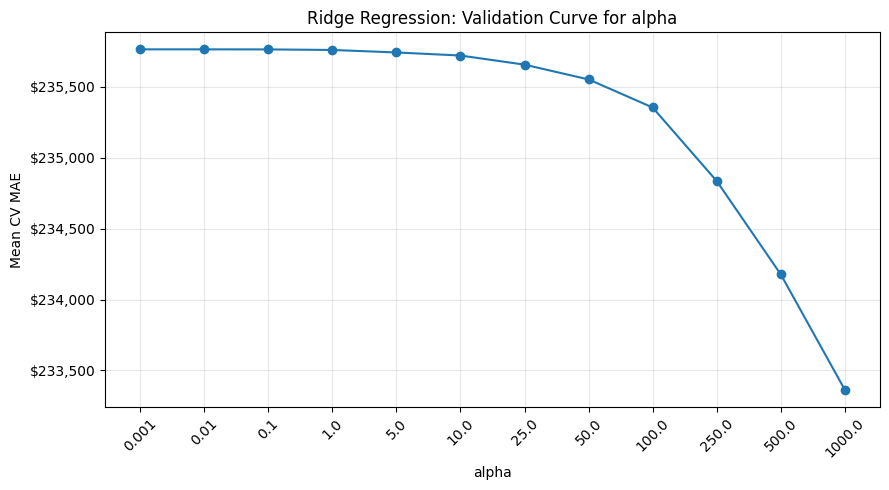

,alpha,Mean CV MAE,CV MAE Std,Elapsed Seconds
0,0.001,235763.082147,3745.066933,1.706545
1,0.010,235763.042690,3745.061453,0.166714
2,0.100,235762.648123,3745.006656,0.170396
3,1.000,235758.705110,3744.459968,0.172473
4,5.000,235741.235771,3742.055627,0.171143
5,10.000,235719.532265,3739.107018,0.169662
6,25.000,235655.242301,3730.582148,0.167409
7,50.000,235551.160771,3717.340554,0.165584
8,100.000,235353.315419,3693.515511,0.163094
9,250.000,234835.438282,3641.767662,0.165476


In [17]:
# ============================================================
# Part 4A — Cell 3: Ridge Validation Curve
# ============================================================

ridge_alpha_values = [
    0.001,
    0.01,
    0.1,
    1,
    5,
    10,
    25,
    50,
    100,
    250,
    500,
    1000
]

ridge_sweep = sweep_parameter(
    model=Ridge(random_state=random_state),
    X=X_train_ridge_sel,
    y=y_train,
    parameter_name="alpha",
    parameter_values=ridge_alpha_values,
    cv=cv,
    model_name="Ridge Regression"
)

display(ridge_sweep)

The initial sweep showed that the lowest validation MAE occurred at the upper end of the search range (alpha = 1000). Since the best result was at the boundary, we expanded the search to larger alpha values to determine whether performance would continue improving or begin to level off.

Ridge Regression (Extended Sweep): SWEEPING alpha


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

alpha = 1000       | Mean MAE = $233,364.75 | Std = $3,575.13 | Time = 0.2s
alpha = 1500       | Mean MAE = $232,964.98 | Std = $3,584.48 | Time = 0.2s
alpha = 2000       | Mean MAE = $232,801.02 | Std = $3,594.73 | Time = 0.2s
alpha = 3000       | Mean MAE = $232,793.06 | Std = $3,615.64 | Time = 0.2s
alpha = 5000       | Mean MAE = $233,145.92 | Std = $3,592.53 | Time = 0.2s
alpha = 7500       | Mean MAE = $233,656.18 | Std = $3,552.90 | Time = 0.2s
alpha = 10000      | Mean MAE = $234,164.81 | Std = $3,534.30 | Time = 0.2s

----------------------------------------------------------------------
Lowest CV MAE: $232,793.06
Parameter value: alpha = 3000.0
CV MAE standard deviation: $3,615.64


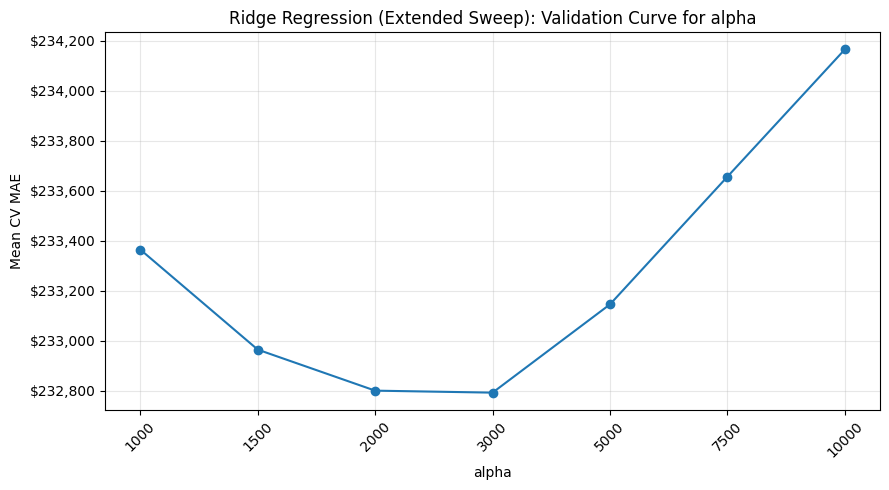

,alpha,Mean CV MAE,CV MAE Std,Elapsed Seconds
0,1000,233364.745131,3575.125031,0.216153
1,1500,232964.975883,3584.475218,0.168129
2,2000,232801.018179,3594.731468,0.170656
3,3000,232793.060027,3615.641203,0.166935
4,5000,233145.919796,3592.528762,0.184435
5,7500,233656.181130,3552.900054,0.179067
6,10000,234164.810181,3534.303157,0.167458


In [18]:
# ============================================================
# Part 4A — Cell 4: Extended Ridge Validation Sweep
# ============================================================

ridge_alpha_values_2 = [
    1000,
    1500,
    2000,
    3000,
    5000,
    7500,
    10000
]

ridge_sweep_2 = sweep_parameter(
    model=Ridge(random_state=random_state),
    X=X_train_ridge_sel,
    y=y_train,
    parameter_name="alpha",
    parameter_values=ridge_alpha_values_2,
    cv=cv,
    model_name="Ridge Regression (Extended Sweep)"
)

display(ridge_sweep_2)

The expanded search showed that validation performance began to level off between approximately 2000 and 3000. Since the improvement across this range was minimal, we performed a focused GridSearchCV to identify the best value. This allowed us to concentrate the search on the most promising region rather than testing unnecessary values.

In [19]:
# ============================================================
# Part 4A — Cell 5: Ridge GridSearchCV
# ============================================================

ridge_grid = {
    "alpha": [
        1500,
        1750,
        2000,
        2250,
        2500,
        2750,
        3000
    ]
}

ridge_search = GridSearchCV(
    estimator=Ridge(random_state=random_state),
    param_grid=ridge_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)

ridge_search.fit(
    X_train_ridge_sel,
    y_train
)

ridge_best = ridge_search.best_estimator_

ridge_scores = -cross_val_score(
    ridge_best,
    X_train_ridge_sel,
    y_train,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1
)

print("="*70)
print("RIDGE GRID SEARCH RESULTS")
print("="*70)

print("Best Parameters:")
print(ridge_search.best_params_)

print()

print(f"Mean CV MAE : ${ridge_scores.mean():,.2f}")
print(f"Std CV MAE  : ${ridge_scores.std():,.2f}")

print()

print(f"Improvement vs Part 3: "
      f"${ridge_part3_mae-ridge_scores.mean():,.2f}")

RIDGE GRID SEARCH RESULTS
Best Parameters:
{'alpha': 2500}

Mean CV MAE : $232,760.68
Std CV MAE  : $3,606.00

Improvement vs Part 3: $2,998.03


After selecting the best hyperparameters, we evaluated the tuned Ridge model using the same repeated 5-fold cross-validation strategy used throughout this milestone. Using the same evaluation procedure makes it easier to compare the tuned model with the Part 3 results and determine whether hyperparameter tuning improved performance.

In [ ]:
# ============================================================
# Part 4A — Cell 6: Focused Grid Search for Ridge (Final Ridge Evaluation)
# ============================================================

ridge_grid = {
    "alpha": [
        1500,
        1750,
        2000,
        2250,
        2500,
        2750,
        3000
    ]
}

ridge_search = GridSearchCV(
    estimator=Ridge(random_state=random_state),
    param_grid=ridge_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

ridge_search.fit(
    X_train_ridge_sel,
    y_train
)

ridge_best = ridge_search.best_estimator_

ridge_tuned_mae = -ridge_search.best_score_

best_index = ridge_search.best_index_

ridge_tuned_std = ridge_search.cv_results_["std_test_score"][best_index]

print("=" * 70)
print("RIDGE GRID SEARCH RESULTS")
print("=" * 70)

print(f"Best Parameters : {ridge_search.best_params_}")
print(f"Mean CV MAE     : ${ridge_tuned_mae:,.2f}")
print(f"CV Std          : ${ridge_tuned_std:,.2f}")
print(f"Improvement     : ${ridge_part3_mae - ridge_tuned_mae:,.2f}")

RIDGE GRID SEARCH RESULTS
Best Parameters : {'alpha': 2500}
Mean CV MAE     : $232,760.68
CV Std          : $3,606.00
Improvement     : $2,998.03


The focused grid search selected alpha = 2500 as the best value. The tuned Ridge model achieved a mean cross-validation MAE of $232,760.68 with a standard deviation of $3,606.00. Compared with the Part 3 result, hyperparameter tuning improved the mean MAE by approximately $2,998.03. Although the improvement was modest, the results show that increasing the regularization strength helped the model generalize slightly better.

In Part 3, Random Forest produced the lowest validation MAE among the three models. Although it performed well using the selected features, it was still using the default hyperparameters. Before tuning multiple parameters, we first explored one of the most influential hyperparameters to better understand how model performance changes across different values. This helps us identify a promising search region before performing a randomized search.

Random Forest: SWEEPING max_depth


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

max_depth = 3          | Mean MAE = $235,934.22 | Std = $3,747.09 | Time = 14.9s
max_depth = 5          | Mean MAE = $215,972.01 | Std = $3,152.80 | Time = 21.3s
max_depth = 7          | Mean MAE = $202,139.39 | Std = $3,238.57 | Time = 29.9s
max_depth = 10         | Mean MAE = $193,002.71 | Std = $3,332.60 | Time = 41.6s
max_depth = 15         | Mean MAE = $188,413.62 | Std = $3,504.17 | Time = 58.9s
max_depth = 20         | Mean MAE = $188,246.60 | Std = $3,510.45 | Time = 72.6s


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81

max_depth = 30         | Mean MAE = $189,220.77 | Std = $3,483.87 | Time = 84.3s
max_depth = None       | Mean MAE = $189,358.68 | Std = $3,412.48 | Time = 83.3s

----------------------------------------------------------------------
Lowest CV MAE: $188,246.60
Parameter value: max_depth = 20.0
CV MAE standard deviation: $3,510.45


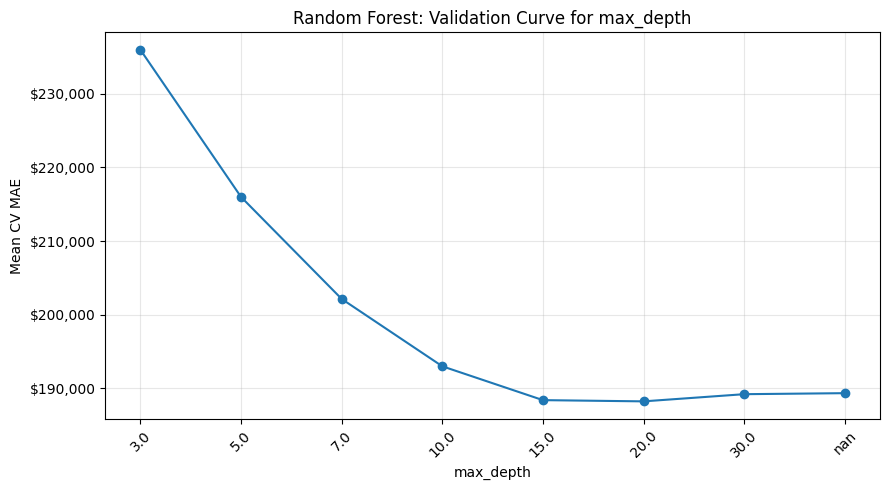

,max_depth,Mean CV MAE,CV MAE Std,Elapsed Seconds
0,3.0,235934.218170,3747.087990,14.878598
1,5.0,215972.014577,3152.796919,21.266230
2,7.0,202139.392704,3238.571480,29.894376
3,10.0,193002.706292,3332.596267,41.629900
4,15.0,188413.616839,3504.170821,58.860757
5,20.0,188246.596819,3510.448497,72.647196
6,30.0,189220.768032,3483.871042,84.294984
7,NaN,189358.675619,3412.475199,83.304111


In [22]:
# ============================================================
# Part 4B — Cell 7: Validation Sweep for Random Forest
# ============================================================

rf_depth_results = sweep_parameter(
    model=RandomForestRegressor(
        random_state=random_state,
        n_jobs=-1
    ),
    X=X_train_rf_sel,
    y=y_train,
    parameter_name="max_depth",
    parameter_values=[
        3,
        5,
        7,
        10,
        15,
        20,
        30,
        None
    ],
    cv=cv,
    model_name="Random Forest"
)

rf_depth_results

The validation sweep showed that performance improved as max_depth increased, but began to level off around a depth of 20. Deeper trees did not improve validation performance and slightly increased the mean CV MAE. Based on these results, we performed a focused randomized search using values centered around this region while also tuning additional Random Forest hyperparameters.

In [23]:
# ============================================================
# Part 4B — Cell 8: Randomized Search for Random Forest
# ============================================================

from scipy.stats import randint

rf_param_dist = {
    "max_depth": [15, 18, 20, 22, 25],
    "min_samples_split": randint(2, 11),
    "min_samples_leaf": randint(1, 6),
    "max_features": ["sqrt", "log2", None],
    "n_estimators": [100, 200, 300]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=random_state
    ),
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=random_state,
    n_jobs=-1,
    return_train_score=True
)

rf_search.fit(
    X_train_rf_sel,
    y_train
)

rf_best = rf_search.best_estimator_

print("=" * 70)
print("RANDOM FOREST RANDOMIZED SEARCH RESULTS")
print("=" * 70)

print("Best Parameters:", rf_search.best_params_)
print(f"Best CV MAE: ${-rf_search.best_score_:,.2f}")

RANDOM FOREST RANDOMIZED SEARCH RESULTS
Best Parameters: {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best CV MAE: $187,339.44


In [24]:
# ============================================================
# Part 4B — Cell 9: Store Tuned Random Forest Results
# ============================================================

rf_best = rf_search.best_estimator_

rf_tuned_mae = -rf_search.best_score_

rf_best_index = rf_search.best_index_

rf_tuned_std = rf_search.cv_results_[
    "std_test_score"
][rf_best_index]

rf_improvement = rf_part3_mae - rf_tuned_mae

print("=" * 70)
print("RANDOM FOREST TUNING RESULTS")
print("=" * 70)

print(f"Best Parameters : {rf_search.best_params_}")
print(f"Mean CV MAE     : ${rf_tuned_mae:,.2f}")
print(f"CV Std          : ${rf_tuned_std:,.2f}")
print(f"Improvement     : ${rf_improvement:,.2f}")

RANDOM FOREST TUNING RESULTS
Best Parameters : {'max_depth': 20, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 300}
Mean CV MAE     : $187,339.44
CV Std          : $3,441.70
Improvement     : $2,019.23


The randomized search selected a Random Forest with max_depth = 20, max_features = None, min_samples_leaf = 5, min_samples_split = 5, and n_estimators = 300. The tuned model achieved a mean cross-validation MAE of $187,339.44 with a standard deviation of $3,441.70. Compared to the Part 3 model, hyperparameter tuning reduced the validation MAE by approximately $2,019.23. Although the improvement was modest, the tuned model generalized slightly better while maintaining the strongest overall performance among the models evaluated so far.

HistGradientBoosting also performed well in Part 3 using the selected features, but it was still using the default hyperparameters. Similar to the previous models, we first explored one of the most influential hyperparameters to identify a promising search region before performing a focused randomized search.

HistGradientBoosting: SWEEPING learning_rate


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for 

learning_rate = 0.01       | Mean MAE = $226,347.94 | Std = $3,665.10 | Time = 3.1s
learning_rate = 0.03       | Mean MAE = $197,799.77 | Std = $3,388.88 | Time = 1.5s
learning_rate = 0.05       | Mean MAE = $193,377.38 | Std = $3,334.96 | Time = 1.4s
learning_rate = 0.07       | Mean MAE = $192,018.56 | Std = $3,275.50 | Time = 1.3s
learning_rate = 0.1        | Mean MAE = $191,801.19 | Std = $3,264.60 | Time = 1.2s
learning_rate = 0.15       | Mean MAE = $191,936.17 | Std = $3,227.62 | Time = 0.9s
learning_rate = 0.2        | Mean MAE = $192,718.27 | Std = $3,422.64 | Time = 0.8s
learning_rate = 0.3        | Mean MAE = $193,681.53 | Std = $3,272.77 | Time = 0.6s

----------------------------------------------------------------------
Lowest CV MAE: $191,801.19
Parameter value: learning_rate = 0.1
CV MAE standard deviation: $3,264.60


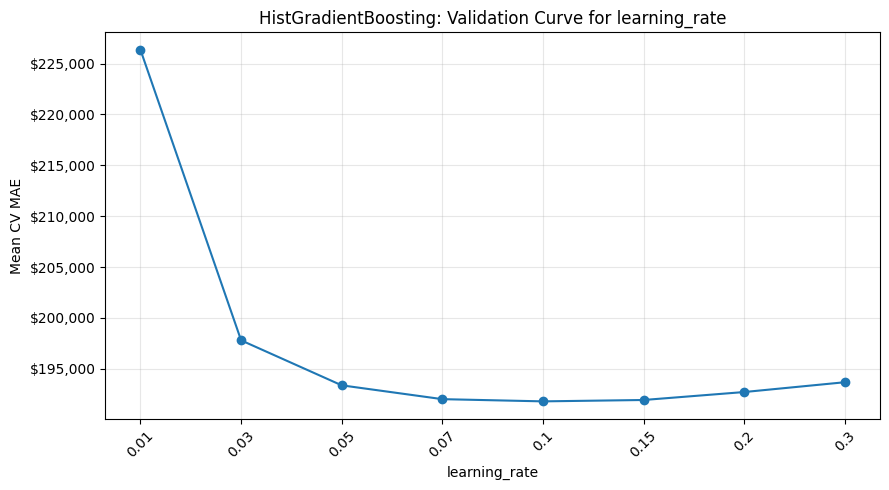

,learning_rate,Mean CV MAE,CV MAE Std,Elapsed Seconds
0,0.01,226347.944931,3665.103598,3.081366
1,0.03,197799.770931,3388.875221,1.482729
2,0.05,193377.380976,3334.961587,1.424581
3,0.07,192018.561684,3275.496406,1.341474
4,0.10,191801.186328,3264.601689,1.201444
5,0.15,191936.170542,3227.622051,0.902371
6,0.20,192718.267469,3422.635035,0.758540
7,0.30,193681.531719,3272.765507,0.643509


In [25]:
# ============================================================
# Part 4C — Cell 10: Validation Sweep for HistGradientBoosting
# ============================================================

hgb_lr_results = sweep_parameter(
    model=HistGradientBoostingRegressor(
        random_state=random_state
    ),
    X=X_train_hgb_sel,
    y=y_train,
    parameter_name="learning_rate",
    parameter_values=[
        0.01,
        0.03,
        0.05,
        0.07,
        0.10,
        0.15,
        0.20,
        0.30
    ],
    cv=cv,
    model_name="HistGradientBoosting"
)

hgb_lr_results

The validation sweep showed that model performance improved as the learning rate increased, with the lowest validation MAE occurring at 0.10. Performance remained similar around 0.15, but began to decline at larger learning rates. Based on these results, we performed a focused randomized search around this region while tuning additional HistGradientBoosting hyperparameters.

In [26]:
# ============================================================
# Part 4C — Cell 11: Randomized Search for HistGradientBoosting
# ============================================================

from scipy.stats import randint

hgb_param_dist = {
    "learning_rate": [0.07, 0.10, 0.12, 0.15],
    "max_depth": [3, 5, 7, None],
    "max_leaf_nodes": randint(15, 41),
    "min_samples_leaf": randint(10, 31),
    "l2_regularization": [0, 0.01, 0.1, 1.0]
}

hgb_search = RandomizedSearchCV(
    estimator=HistGradientBoostingRegressor(
        random_state=random_state
    ),
    param_distributions=hgb_param_dist,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=cv,
    random_state=random_state,
    n_jobs=-1,
    return_train_score=True,
    verbose=2
)

hgb_search.fit(
    X_train_hgb_sel,
    y_train
)

hgb_best = hgb_search.best_estimator_

print("=" * 70)
print("HISTGRADIENTBOOSTING RANDOMIZED SEARCH RESULTS")
print("=" * 70)

print("Best Parameters:", hgb_search.best_params_)
print(f"Best CV MAE: ${-hgb_search.best_score_:,.2f}")

Fitting 25 folds for each of 10 candidates, totalling 250 fits
[CV] END l2_regularization=0.1, learning_rate=0.15, max_depth=3, max_leaf_nodes=29, min_samples_leaf=20; total time=   0.1s
[CV] END l2_regularization=0.1, learning_rate=0.15, max_depth=3, max_leaf_nodes=29, min_samples_leaf=20; total time=   0.2s
[CV] END l2_regularization=0.1, learning_rate=0.15, max_depth=3, max_leaf_nodes=29, min_samples_leaf=20; total time=   0.2s
[CV] END l2_regularization=0.1, learning_rate=0.15, max_depth=3, max_leaf_nodes=29, min_samples_leaf=20; total time=   0.2s
[CV] END l2_regularization=0.1, learning_rate=0.15, max_depth=3, max_leaf_nodes=29, min_samples_leaf=20; total time=   0.2s
[CV] END l2_regularization=0.1, learning_rate=0.15, max_depth=3, max_leaf_nodes=29, min_samples_leaf=20; total time=   0.2s
[CV] END l2_regularization=0.1, learning_rate=0.15, max_depth=3, max_leaf_nodes=29, min_samples_leaf=20; total time=   0.2s
[CV] END l2_regularization=0.1, learning_rate=0.15, max_depth=3, max_

In [27]:
# ============================================================
# Part 4C — Cell 12: Store Tuned HistGradientBoosting Results
# ============================================================

hgb_best = hgb_search.best_estimator_

hgb_tuned_mae = -hgb_search.best_score_

hgb_best_index = hgb_search.best_index_

hgb_tuned_std = hgb_search.cv_results_[
    "std_test_score"
][hgb_best_index]

hgb_improvement = hgb_part3_mae - hgb_tuned_mae

print("=" * 70)
print("HISTGRADIENTBOOSTING TUNING RESULTS")
print("=" * 70)

print(f"Best Parameters : {hgb_search.best_params_}")
print(f"Mean CV MAE     : ${hgb_tuned_mae:,.2f}")
print(f"CV Std          : ${hgb_tuned_std:,.2f}")
print(f"Improvement     : ${hgb_improvement:,.2f}")

HISTGRADIENTBOOSTING TUNING RESULTS
Best Parameters : {'l2_regularization': 0.1, 'learning_rate': 0.12, 'max_depth': 7, 'max_leaf_nodes': 38, 'min_samples_leaf': 30}
Mean CV MAE     : $191,240.16
CV Std          : $3,191.91
Improvement     : $561.03


After tuning all three models, we compared their validation performance using the same repeated 5-fold cross-validation procedure. While each model showed some improvement after hyperparameter tuning, the magnitude of the improvement varied. Ridge Regression showed the largest reduction in validation MAE, followed by Random Forest and HistGradientBoosting. Despite the smaller improvement from tuning, Random Forest remained the best-performing model overall, achieving the lowest validation MAE among all three models.

### 4.B Discussion

Answer the following questions.

#### 4.B.1

Which hyperparameters had the greatest impact on model performance? Briefly explain.

The hyperparameters with the greatest impact on model performance were alpha for Ridge Regression, max_depth for Random Forest, and learning_rate for HistGradientBoosting. The validation curves showed that these parameters had the largest influence on validation MAE and helped identify promising regions for further tuning. Additional hyperparameters, such as min_samples_leaf, min_samples_split, max_leaf_nodes, and l2_regularization, provided further improvements when tuned together using randomized search.

#### 4.B.2

Did hyperparameter tuning substantially improve the performance of all three models, or only some of them?

Hyperparameter tuning improved the performance of all three models, although the amount of improvement varied. Ridge Regression showed the largest improvement, reducing the validation MAE by approximately $2,998. Random Forest also improved by about $2,019, while HistGradientBoosting showed a smaller improvement of approximately $561. These results suggest that tuning was beneficial for all models, but models that were already performing well had less room for improvement.

#### 4.B.3

Which tuning method(s) did you use for each model? Briefly explain why you chose those methods.

We first used validation curves to evaluate one important hyperparameter for each model and identify a promising search region. For Ridge Regression, we followed the validation sweep with a focused GridSearchCV because only one primary hyperparameter (alpha) needed to be optimized. For Random Forest and HistGradientBoosting, we used RandomizedSearchCV because both models contain several important hyperparameters. This approach allowed us to efficiently search multiple combinations while keeping the computational cost manageable.

#### 4.B.4

After tuning, how did the relative performance of your three models change? Did tuning affect which model appeared to perform best?

Hyperparameter tuning improved the validation performance of all three models, but it did not change their overall ranking. Random Forest remained the best-performing model, achieving the lowest validation MAE after tuning. HistGradientBoosting remained the second-best model, followed by Ridge Regression. Although Ridge Regression showed the largest improvement from tuning, Random Forest still produced the strongest overall predictive performance.

## Part 5: Final Model and Workflow Assessment [14 pts]

### 5.A Coding

Using the work completed in **Parts 1–4**:

Select your **best-performing model** and prepare your final modeling pipeline.

Your pipeline should include all preprocessing, feature engineering, feature selection, and hyperparameter tuning decisions that you chose to retain.

Evaluate your final model by:

* Training on the complete training dataset.
* Reporting the **mean** and **standard deviation** of the repeated cross-validation MAE.
* Evaluating the model on the held-out test set.
* Reporting the final test MAE.

In [13]:
# Add as many code cells as needed.

### 5.B Discussion

Answer the following questions.

#### 5.B.1

Compare the performance of your final model with its original baseline from **Part 1**. Which changes contributed the most to the improvement?

> Replace this text with your answer.

#### 5.B.2

Looking back at the hypotheses you proposed in **Milestone 1**, which were supported by your experimental results? Were any hypotheses disproved?

> Replace this text with your answer.

#### 5.B.3

Why did you select this model as your final model? Discuss both its predictive performance and any other considerations (such as stability, simplicity, or interpretability).

> Replace this text with your answer.

#### 5.B.4

What did you learn about your dataset and the machine learning process through this end-to-end modeling workflow? If you had additional time, what would you investigate next?

> Replace this text with your answer.